# Zad 1.

Wyobraź sobie, że budujesz system monitorowania dla zakładu produkcyjnego. Czujniki zbierają dane, aby określić, czy maszyna działa prawidłowo, czy też wystąpiła awaria. Chociaż rzeczywiste dane z czujników są złożone, zasymulujemy je za pomocą syntetycznego zbioru danych "two-moons", który zawiera klasy nierozdzielne liniowo.

Twoim zadaniem jest zbudowanie wielowarstwowej sieci typu MLP do klasyfikacji wyników pomiarów.

Wskazówki:
- Zbuduj wielowarstwowy perceptron (MLP) z co najmniej dwiema warstwami ukrytymi.  
- Podziel dane na zbiór testowy oraz treningowy
- Wytrenuj model, używając odpowiedniej do problemu funckji straty.  

Szablon rozwiązania podany jest poniżej.

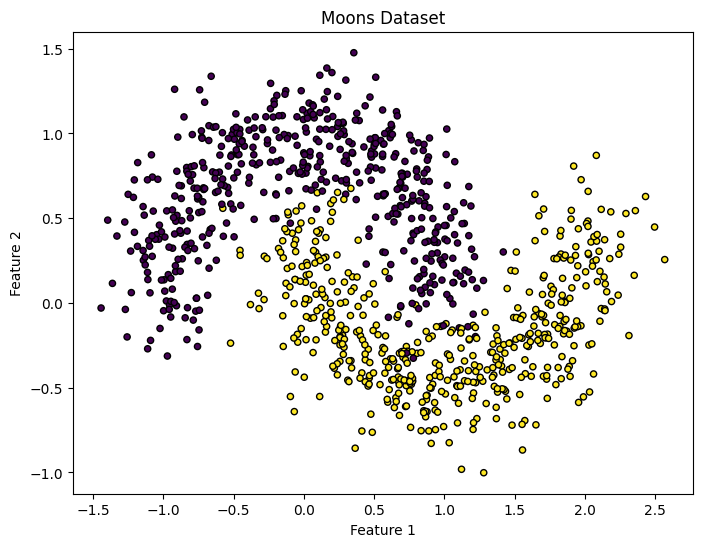

TypeError: zeros_like(): argument 'input' (position 1) must be Tensor, not numpy.ndarray

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Fikcyjne dane pomiarowe
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

# Wykres
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=20, edgecolor='k')
plt.title("Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# TODO: podział danych na zb. treningowy oraz testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
loss = nn.MSELoss()


class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        # TODO: Warstwy sieci


    def forward(self, x):
        # TODO: Obliczenia fazy "w przód"
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.softmax(self.fc3(x), dim=1)

        return torch.zeros_like(x[-1])

model = MLP()

loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


# Trening
for epoch in range(100):
    # TODO
    model.train()
    optimizer.zero_grad()
    logits = model(X_train)
    loss = loss_fn(logits, y_train)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/100], Loss: {loss.item():.4f}")


# Ewaluacja modelu
model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    y_pred_class = (y_pred > 0.5).float()
    accuracy = (y_pred_class == y_test).float().mean()
    print(f"Test Accuracy: {accuracy.item():.4f}")


# Wykres poprawnie / niepoprawnie sklasyfikowanych punktów danych
with torch.no_grad():
    correct_idx = (y_pred_class == y_test).view(-1).numpy()
    misclassified_idx = (y_pred_class != y_test).view(-1).numpy()
    X_test_np = X_test.numpy()
    y_test_np = y_test.numpy().flatten()

plt.figure(figsize=(8, 6))
# Poprawna klasyfikacja -- kolor szary
plt.scatter(X_test_np[correct_idx, 0], X_test_np[correct_idx, 1],
            c='lightgray', label='Correctly Classified', s=50, edgecolor='k')
# Błędna -- kolor czerwony
plt.scatter(X_test_np[misclassified_idx, 0], X_test_np[misclassified_idx, 1],
            c='red', label='Misclassified', s=50, edgecolor='k')
plt.legend()
plt.show()

# Zad. 2.

Opracuj model prognozujący liczbę dziennych wypożyczeń rowerów w systemie Capital Bikeshare (Waszyngton, D.C.) na podstawie danych historycznych zawartych w zbiorze "Daily Bike Rentals" z UCI Machine Learning Repository. Wartość docelowa to liczba wypożyczeń rowerów na dzień (kolumna **cnt**), która jest nieujemną liczbą całkowitą i podąża za rozkładem [rozkładem Poissona](https://pl.wikipedia.org/wiki/Rozk%C5%82ad_Poissona)

Zbiór danych zawiera 731 dziennych obserwacji z cechami takimi jak: temperatura (**temp**), wilgotność (**hum**), prędkość wiatru (**windspeed**), pora roku (**season**), warunki pogodowe (**weathersit**) oraz zmienne związane z datą (np. **yr**, **mnth**, **weekday**).


Wskazówki:

* Zaimplementuj funkcję straty:
$$L = \frac{1}{N} \sum_{i=1}^N \left( \hat{y}_i - y_i \log(\hat{y}_i) \right)$$
gdzie:
$\hat{y}_i$ jest wart. predykowaną a $y_i$ prawdziwą.

* Zastosuj sieć MLP z 2 warstwami ukrytymi

* Ponieważ przewidywane liczby wypożyczeń muszą być nieujemne, należy zastosować funkcję aktywacji **Softplus** w warstwie wyjściowej MLP.

* Jakich zmian należy dokonać, żeby móc zastosować `torch.nn.PoissonNLLLoss` -- zmodyfikuj implementację i sprawdź działanie

## Przygotowanie danych

In [31]:
import pandas as pd

df = pd.read_csv("day.csv")
target = df["cnt"]
features = df.drop(columns=["cnt", "instant", "dteday"])  # Odrzuć ID oraz datę

In [32]:
features

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered
0,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654
1,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670
2,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229
3,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454
4,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518
...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867
727,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451
728,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182
729,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432


## Szkic rozwiązania

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = features.values
y = target.values

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

# Podział na zb. treningowy i testowy
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(X, y, test_size=0.4, random_state=42)

# Normalizacja wartości
scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train_np)
X_test_np = scaler.transform(X_test_np)

X_train = torch.tensor(X_train_np, dtype=torch.float32)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test_np, dtype=torch.float32).view(-1, 1)

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(13, 32),
            nn.ReLU(),
            nn.Linear(32, 13),
            nn.ReLU(),
            nn.Linear(13, 1),
            # Softplus jest OK dla rozkładu Poissona (zwraca wartości > 0)
            nn.Softplus()
        )

    def forward(self, x):
        return self.net(x)

def poisson_loss(pred, target):
    return (pred - target * torch.log(pred + 1e-8)).mean()

model = MLP()
loss_fn = poisson_loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1000):
    model.train()
    optimizer.zero_grad()

    preds = model(X_train)
    loss = loss_fn(preds, y_train)

    loss.backward()  # <--- TEGO BRAKOWAŁO! Bez tego wagi stoją w miejscu.
    optimizer.step()

# Ocena
model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    mse = nn.MSELoss()(y_pred, y_test)
    print(f"Błąd MSE: {mse.item():.4f}")

    # Predykcje vs rzeczywiste wartości
    print("Przykładowe predykcje vs rzeczywiste wart.:")
    for i in range(10):
        print(f"Pred: {y_pred[i].item():.2f}, True: {y_test[i].item()}")

X shape: (731, 13)
y shape: (731,)
Błąd MSE: 20262004.0000
Przykładowe predykcje vs rzeczywiste wart.:
Pred: 364.55, True: 6606.0
Pred: 292.95, True: 1550.0
Pred: 184.97, True: 3747.0
Pred: 201.07, True: 6041.0
Pred: 406.32, True: 7538.0
Pred: 489.48, True: 7264.0
Pred: 283.85, True: 1605.0
Pred: 153.63, True: 2209.0
Pred: 517.23, True: 7499.0
Pred: 345.67, True: 5743.0


# Zad. 3.

Firma kurierska chce przewidywać **czas dostawy paczki** na podstawie cech takich jak:
- odległość,
- liczba paczek obsługiwanych przez kuriera,
- waga paczki,
- natężenie ruchu.

Dane historyczne zawierają jednak **obserwacje odstające**: część dostaw była mocno opóźniona przez awarie, korki lub błędne wpisy. Twoim zadaniem jest sprawdzić, jak wybór funkcji straty wpływa na uczenie modelu MLP w takim przypadku.

Wygeneruj syntetyczny zbiór danych regresyjnych, a następnie celowo dodaj do części próbek duży błąd losowy (*outliery*).

Wskazówki:
* Zbuduj model MLP z 1 lub 2 warstwami ukrytymi.
* Wytrenuj model osobno dla funkcji strat:
  - `torch.nn.MSELoss()`,
  - `torch.nn.L1Loss()`,
  - `torch.nn.HuberLoss()` lub `torch.nn.SmoothL1Loss()`.

Porównaj modele za pomocą:
- **MAE**,
- **MSE**,
- wykresu: wartości rzeczywiste vs przewidywane.

Pytania:
1. Która funkcja straty najlepiej radzi sobie w obecności obserwacji odstających?
2. Dlaczego `MSELoss` jest bardziej wrażliwa na duże błędy niż `L1Loss`?
3. Jak zmienia się przebieg uczenia dla `HuberLoss` w porównaniu z `MSELoss`?
4. Czy model uczony z funkcją odporną na outliery lepiej przewiduje większość typowych przypadków?

,distance_km,courier_load,package_weight_kg,traffic_level
0,0.876169,-0.061076,-0.668345,0.540909
1,-0.011092,0.823280,-0.813014,0.322082
2,0.519902,0.419706,1.868818,-1.373403
3,-0.224765,-1.801980,-1.170113,-1.366879
4,0.018850,0.233216,0.708214,-0.098588


MSE: epoch 50, loss = 6170.0903
MSE: epoch 100, loss = 2236.1064
MSE: epoch 150, loss = 2090.8447
MSE: epoch 200, loss = 2041.5254
MSE: epoch 250, loss = 2005.1794
MSE: epoch 300, loss = 1986.5905
MSE: epoch 350, loss = 1970.5996
MSE: epoch 400, loss = 1959.8042
MSE: epoch 450, loss = 1949.6804
MSE: epoch 500, loss = 1939.7489
MSE: epoch 550, loss = 1931.0259
MSE: epoch 600, loss = 1922.3987
MSE: epoch 650, loss = 1912.5577
MSE: epoch 700, loss = 1904.7507
MSE: epoch 750, loss = 1895.2142
MSE: epoch 800, loss = 1887.1633
MSE: epoch 850, loss = 1879.1866
MSE: epoch 900, loss = 1872.1718
MSE: epoch 950, loss = 1865.8026
MSE: epoch 1000, loss = 1858.2935
L1: epoch 50, loss = 42.3097
L1: epoch 100, loss = 19.4770
L1: epoch 150, loss = 17.8925
L1: epoch 200, loss = 17.2620
L1: epoch 250, loss = 16.9504
L1: epoch 300, loss = 16.7746
L1: epoch 350, loss = 16.6494
L1: epoch 400, loss = 16.6235
L1: epoch 450, loss = 16.5364
L1: epoch 500, loss = 16.5087
L1: epoch 550, loss = 16.4859
L1: epoch 6

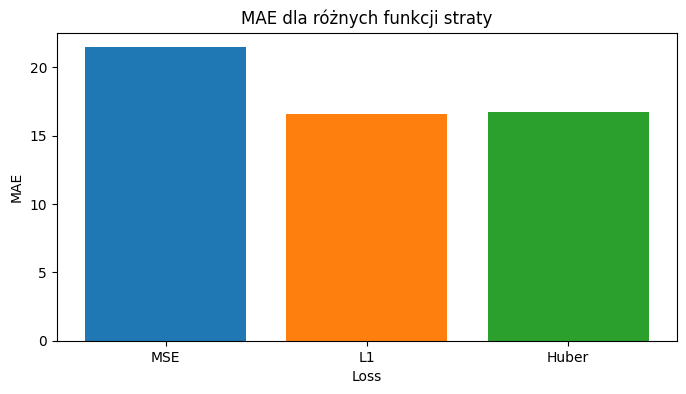

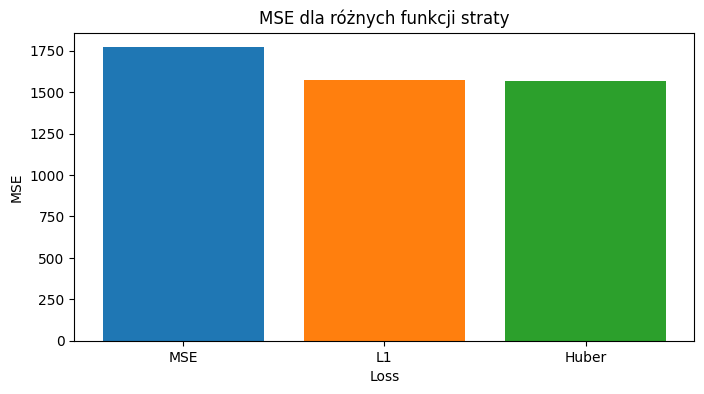

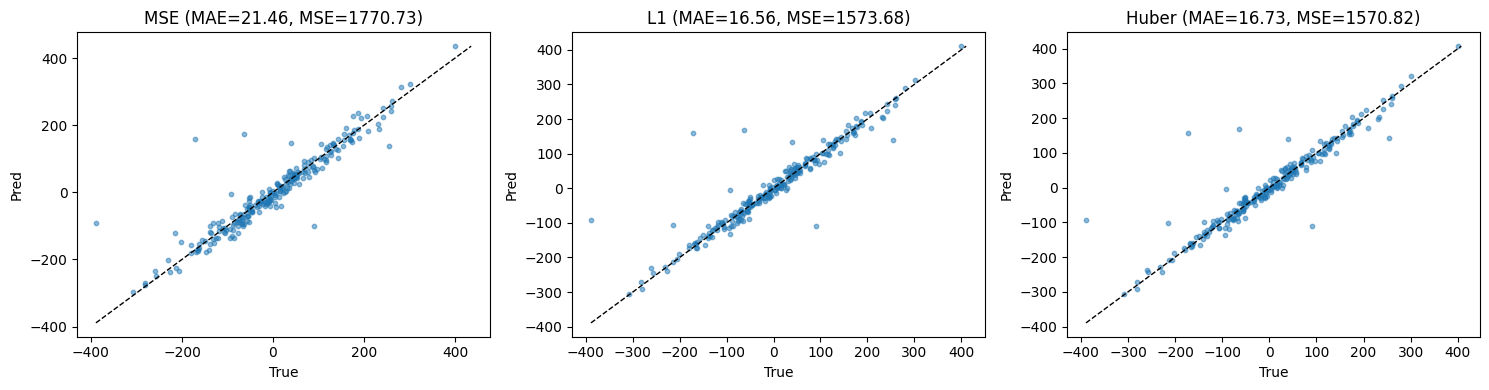

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Dane syntetyczne: czas dostawy zależny od kilku cech oraz szumu
feature_names = ['distance_km', 'courier_load', 'package_weight_kg', 'traffic_level']
X, y = make_regression(n_samples=1200, n_features=4, noise=12.0, random_state=42)
X = pd.DataFrame(X, columns=feature_names)
y = y.astype(np.float32)
display(X.head())

# Dodajemy obserwacje odstające
rng = np.random.default_rng(42)
outlier_idx = rng.choice(len(y), size=60, replace=False)
y[outlier_idx] += rng.normal(loc=0.0, scale=250.0, size=len(outlier_idx)).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
input_dim = X_train.shape[1]

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

class DeliveryMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # TODO: 1 lub 2 warstwy ukryte
                nn.Linear(input_dim, 32),
                nn.ReLU(),
                nn.Linear(32, 16),
                nn.ReLU(),
                nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

# HuberLoss zachowuje sie jak MSE dla malych bledow i bardziej jak L1 dla duzych.
# Parametr delta wyznacza granice miedzy tymi dwoma zakresami.
loss_fns = {
    'MSE': nn.MSELoss(),
    'L1': nn.L1Loss(),
    'Huber': nn.HuberLoss(delta=10.0),
}

results = {}

for loss_name, loss_fn in loss_fns.items():
    model = DeliveryMLP()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(200):
        model.train()
        optimizer.zero_grad()
        pred = model(X_train)
        loss = loss_fn(pred, y_train)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 50 == 0:
            print(f'{loss_name}: epoch {epoch+1}, loss = {loss.item():.4f}')

    model.eval()
    with torch.no_grad():
        y_pred = model(X_test)
        mae = nn.L1Loss()(y_pred, y_test).item()
        mse = nn.MSELoss()(y_pred, y_test).item()
        results[loss_name] = {'mae': mae, 'mse': mse, 'pred': y_pred.numpy()}

for loss_name, metrics in results.items():
    print(f"{loss_name}: MAE = {metrics['mae']:.2f}, MSE = {metrics['mse']:.2f}")

names = list(results.keys())
maes = [results[n]['mae'] for n in names]
mses = [results[n]['mse'] for n in names]

plt.figure(figsize=(8,4))
plt.bar(names, maes, color=['C0','C1','C2'])
plt.title('MAE dla różnych funkcji straty')
plt.ylabel('MAE')
plt.xlabel('Loss')
plt.show()

plt.figure(figsize=(8,4))
plt.bar(names, mses, color=['C0','C1','C2'])
plt.title('MSE dla różnych funkcji straty')
plt.ylabel('MSE')
plt.xlabel('Loss')
plt.show()

y_test_np = y_test.numpy().flatten()

plt.figure(figsize=(15,4))
for i, name in enumerate(names):
    preds = np.array(results[name]['pred']).flatten()  # flatenowanie na 1D
    plt.subplot(1, len(names), i+1)
    plt.scatter(y_test_np, preds, alpha=0.5, s=10)
    # linia idealnej zgody
    mn = min(y_test_np.min(), preds.min())
    mx = max(y_test_np.max(), preds.max())
    plt.plot([mn, mx], [mn, mx], 'k--', linewidth=1)
    plt.xlabel('True')
    plt.ylabel('Pred')
    plt.title(f'{name} (MAE={results[name]["mae"]:.2f}, MSE={results[name]["mse"]:.2f})')

plt.tight_layout()
plt.show()

# Przykład -- model dwuzadaniowy

Poniższy przykład ilustruje w jaki sposób możemy tworzyć i trenować modele
**wielozadaniowe**, np. regresja + klasyfikacja.

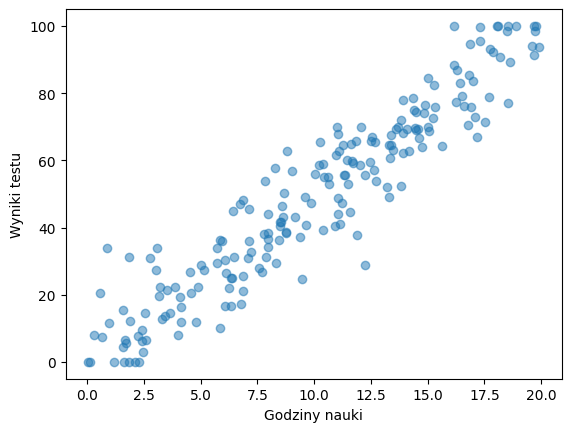

In [59]:
# Generujemy dane do regresji -- czas nauki a wyniki na teście

import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Generowanie danych syntetycznych
np.random.seed(123)
N = 200  # liczba studentów

hours_studied = np.random.uniform(0, 20, N)
test_scores = 5 * hours_studied + np.random.normal(0, 10, N)  # wynik z szumem
test_scores = np.clip(test_scores, 0, 100)  # zakres wyników 0-100
passed = (test_scores >= 50).astype(int)

# Wykres
plt.scatter(hours_studied, test_scores, alpha=0.5)
plt.xlabel('Godziny nauki')
plt.ylabel('Wyniki testu')
plt.show()

Teraz dodajmy podział na **klasy**:
- *zdał* -- dla >= 50 pkt.
- *oblał* -- dla < 50 pkt.

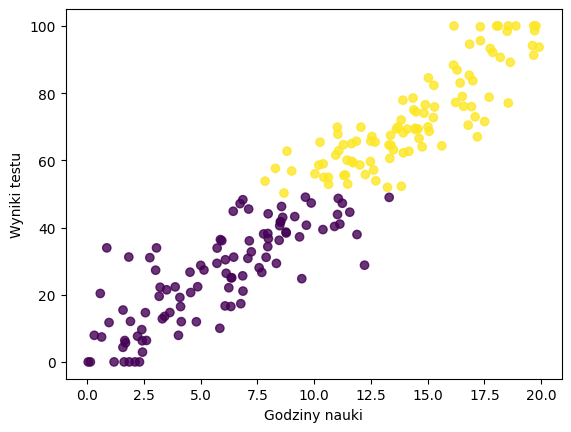

In [60]:
passed = (test_scores >= 50).astype(int)

# Podział danych
X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    hours_studied.reshape(-1,1), test_scores, passed, test_size=0.2, random_state=42
)

# Wykres
plt.scatter(hours_studied, test_scores, c=passed, alpha=0.8)
plt.xlabel('Godziny nauki')
plt.ylabel('Wyniki testu')
plt.show()

Na tej podstawie możemy zbudować zbiór danych dla naszego dwuzadaniowego modelu.

In [62]:
import torch
from torch.utils.data import Dataset, DataLoader

# Podział danych
X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    hours_studied.reshape(-1,1), test_scores, passed,
    test_size=0.2
)

# Dane możemy opakować w klasę StudentDataset dla wygody korzystania
# z treningu grupami (batch)

class StudentDataset(Dataset):
    def __init__(self, X, y_reg, y_cls):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_reg = torch.tensor(y_reg, dtype=torch.float32)
        self.y_cls = torch.tensor(y_cls, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Dla każdego X zwracamy wynik regresji oraz klasę
        return self.X[idx], self.y_reg[idx], self.y_cls[idx]


train_ds = StudentDataset(X_train, y_reg_train, y_cls_train)
test_ds = StudentDataset(X_test, y_reg_test, y_cls_test)

# Porcje po 16 elementów
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16)

# Podgląd
for X_batch, y_reg_batch, y_cls_batch in train_loader:
    print(X_batch.shape, y_reg_batch.shape, y_cls_batch.shape)
    for hours, score, cls in zip(X_batch, y_reg_batch, y_cls_batch):
        print(f'{hours = } {score = } {cls = }')
    break

torch.Size([16, 1]) torch.Size([16]) torch.Size([16])
hours = tensor([8.4861]) score = tensor(40.5477) cls = tensor(0.)
hours = tensor([0.6440]) score = tensor(7.4155) cls = tensor(0.)
hours = tensor([3.0225]) score = tensor(27.3026) cls = tensor(0.)
hours = tensor([9.4583]) score = tensor(24.7759) cls = tensor(0.)
hours = tensor([6.2452]) score = tensor(22.0731) cls = tensor(0.)
hours = tensor([11.5710]) score = tensor(44.5644) cls = tensor(0.)
hours = tensor([17.8678]) score = tensor(92.1257) cls = tensor(1.)
hours = tensor([5.0091]) score = tensor(28.7417) cls = tensor(0.)
hours = tensor([19.9072]) score = tensor(93.7005) cls = tensor(1.)
hours = tensor([1.6356]) score = tensor(0.) cls = tensor(0.)
hours = tensor([8.6740]) score = tensor(50.2531) cls = tensor(1.)
hours = tensor([12.6880]) score = tensor(65.4359) cls = tensor(1.)
hours = tensor([18.5515]) score = tensor(77.0651) cls = tensor(1.)
hours = tensor([0.8718]) score = tensor(33.9454) cls = tensor(0.)
hours = tensor([18.8832

Epoch 20, Loss: 78.0713
Epoch 40, Loss: 74.6215
Epoch 60, Loss: 74.0500
Epoch 80, Loss: 73.3178
Epoch 100, Loss: 73.0527

Regresja - MAE: 8.20
Klasyfikacja - dokładność: 0.90


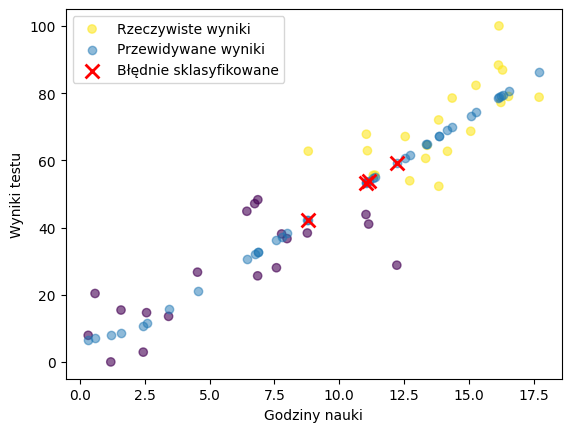

In [63]:
import torch
import torch.nn as nn
import torch.optim as optim


class SimpleMultiTaskModel(nn.Module):
    def __init__(self):
        super().__init__()
        backbone_output_size = 10
        # Część wspólna (kręgosłup modelu, ang. backbone)
        self.shared = nn.Sequential(
            nn.Linear(1, backbone_output_size),
            nn.ReLU()
        )
        # Głowice modelu -- po jednej dla zadania.
        # Wejściem głowicy jest wynik części wspólnej

        # Głowica dla regresji
        self.regression = nn.Linear(backbone_output_size, 1)

        # Głowica dla klasyfikacji
        self.classification = nn.Sequential(
            nn.Linear(backbone_output_size, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        shared_out = self.shared(x)  # wynik części wspólnej
        #                           / regresja     \ klasyfikacja
        #                          v                v
        return self.regression(shared_out), self.classification(shared_out)


# Trening
model = SimpleMultiTaskModel()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Uwaga -- 2 funkcje straty, bo 2 zadania:
reg_loss_fn = nn.MSELoss()
cls_loss_fn = nn.BCELoss()

for epoch in range(100):
    model.train()
    total_loss = 0
    for X_batch, y_reg_batch, y_cls_batch in train_loader:
        optimizer.zero_grad()

        reg_pred, cls_pred = model(X_batch)

        reg_loss = reg_loss_fn(reg_pred.squeeze(), y_reg_batch)
        cls_loss = cls_loss_fn(cls_pred.squeeze(), y_cls_batch)
        loss = reg_loss + cls_loss

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")


# Ewaluacja
model.eval()
with torch.no_grad():
    reg_preds, cls_preds = model(torch.tensor(X_test, dtype=torch.float32))
    reg_preds = reg_preds.squeeze().numpy()
    cls_preds = (cls_preds.squeeze().numpy() > 0.5).astype(int)

# Błąd regresji, tj. MAE (ang. Mean Abs. Error)
reg_mae = np.mean(np.abs(reg_preds - y_reg_test))
# Dokładność klasyfikacji
cls_accuracy = np.mean(cls_preds == y_cls_test)

print(f"\nRegresja - MAE: {reg_mae:.2f}")
print(f"Klasyfikacja - dokładność: {cls_accuracy:.2f}")

misclassified = y_cls_test != cls_preds

# Wizualizacja
plt.scatter(X_test, y_reg_test, c=y_cls_test, label='Rzeczywiste wyniki', alpha=0.6)
plt.scatter(X_test, reg_preds, label='Przewidywane wyniki', alpha=0.5)

plt.scatter(X_test[misclassified], reg_preds[misclassified], c='red', marker='x', s=100,
            label='Błędnie sklasyfikowane', linewidths=2)

plt.xlabel('Godziny nauki')
plt.ylabel('Wyniki testu')
plt.legend()
plt.show()


# Zad. 4

Jako analityk danych edukacyjnych chcesz jednocześnie przewidywać końcowe wyniki uczniów z **dwóch przedmiotów**: matematyki oraz języka portugalskiego. Celem jest sprawdzenie, czy **model wielozadaniowy** (*multi-task learning*) potrafi wykorzystać wspólną reprezentację cech ucznia lepiej niż dwa osobne modele.

Rozważ dwa zadania regresyjne:

1. przewidywanie końcowej oceny z matematyki (`G3_mat`),
2. przewidywanie końcowej oceny z języka portugalskiego (`G3_por`).

W zadaniu wykorzystaj zbiór danych  
[UCI Machine Learning Repository - Student Performance](https://archive.ics.uci.edu/dataset/320/student+performance)

Zbiór zawiera dwa pliki:
- `student-mat.csv` — wyniki z matematyki,
- `student-por.csv` — wyniki z języka portugalskiego.

Należy połączyć rekordy tych samych uczniów z obu plików tak, aby uzyskać:
- wspólny wektor cech wejściowych,
- dwa cele wyjściowe: `G3_mat` oraz `G3_por`.

## Polecenia

1. Przygotuj dane:
   - zakoduj cechy kategoryczne,
   - przeskaluj cechy numeryczne,
   - usuń cechy przewidywane (y),
   - podziel dane w stosunku **80/20** na zbiór treningowy i testowy.

2. Zbuduj model typu **MLP** z:
   - częścią wspólną,
   - dwoma wyjściami regresyjnymi.

3. Sprawdź model dla:
   - **1 oraz 2 warstw ukrytych**,
   - liczby neuronów **nie większej niż 100** w warstwie,
   - liczby epok **nie większej niż 500**.

4. Przyjmij funkcję straty w postaci sumy strat obu zadań, np.

   $$
   L = L_{mat} + L_{por}
   $$

5. Sprawdź wpływ wag w funkcji straty, np.
   $$
   L = 10 \cdot L_{mat} + L_{por}
   \qquad \text{oraz} \qquad
   L = L_{mat} + 10 \cdot L_{por}
   $$

6. Wytrenuj również **dwa osobne modele MLP**:
   - jeden przewidujący tylko `G3_mat`,
   - drugi przewidujący tylko `G3_por`.

7. Porównaj wyniki modelu wielozadaniowego i modeli osobnych, używając miar regresji, np.:
   - **MAE**,
   - **RMSE**.

## Pytania

1. Czy model wielozadaniowy uzyskał lepsze wyniki niż dwa osobne modele?
2. Czy współdzielenie warstw ukrytych poprawiło przewidywanie wyników obu przedmiotów?
3. Jak zmiana wag w funkcji straty wpływa na wyniki obu zadań?
4. Czy wyniki sugerują, że osiągnięcia ucznia z matematyki i języka portugalskiego mają wspólne uwarunkowania, które model może wykorzystać?

## Dodatkowo

Warto porównać dwa warianty:
- model wykorzystujący wcześniejsze oceny (`G1`, `G2`),
- model bez wcześniejszych ocen.

## Pobranie danych

In [65]:
import pandas as pd
import requests
import zipfile
import io
from sklearn.preprocessing import StandardScaler

def load_data(url, file_name):
    response = requests.get(url)
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        with z.open(file_name) as f:
            df = pd.read_csv(f, sep=';')
    return df

def preprocess_data(df):
    # TODO

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"
file_name = 'student-mat.csv'
df = load_data(url, file_name)
# X, y_reg, y_cls = preprocess_data(df)

IndentationError: expected an indented block after function definition on line 14 (1373411455.py, line 17)